In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from statsmodels.distributions.empirical_distribution import ECDF

# ЭФР

1) Пусть Xi ∼ N (0, 1).

  1.1) Построить эмпирическую функцию распределения (ЭФР) на одном графике с теоретической функцией распределения при разных n (проиллюстрировать сходимость ЭФР к ф.р.). То же для Xi ∼ R[0, 1], Xi ∼ Bin(m, p), где m = 3, m = 10.

  1.2)  Построить 95% доверительную полосу для ф.р., используя
   а) критерий Колмогорова.
   б) неравенство Дворецкого-Кифера-Вольфовица.

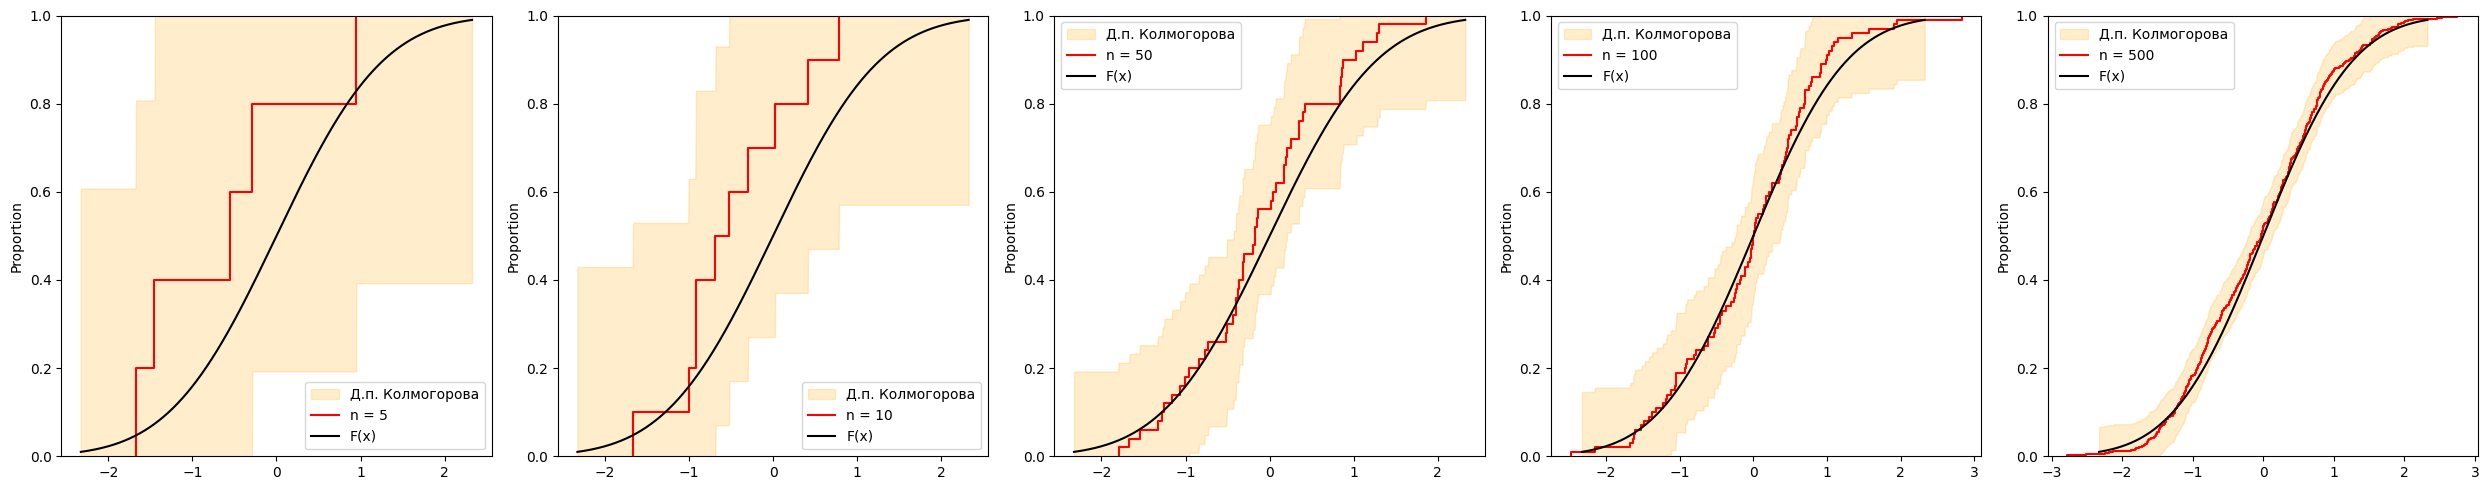

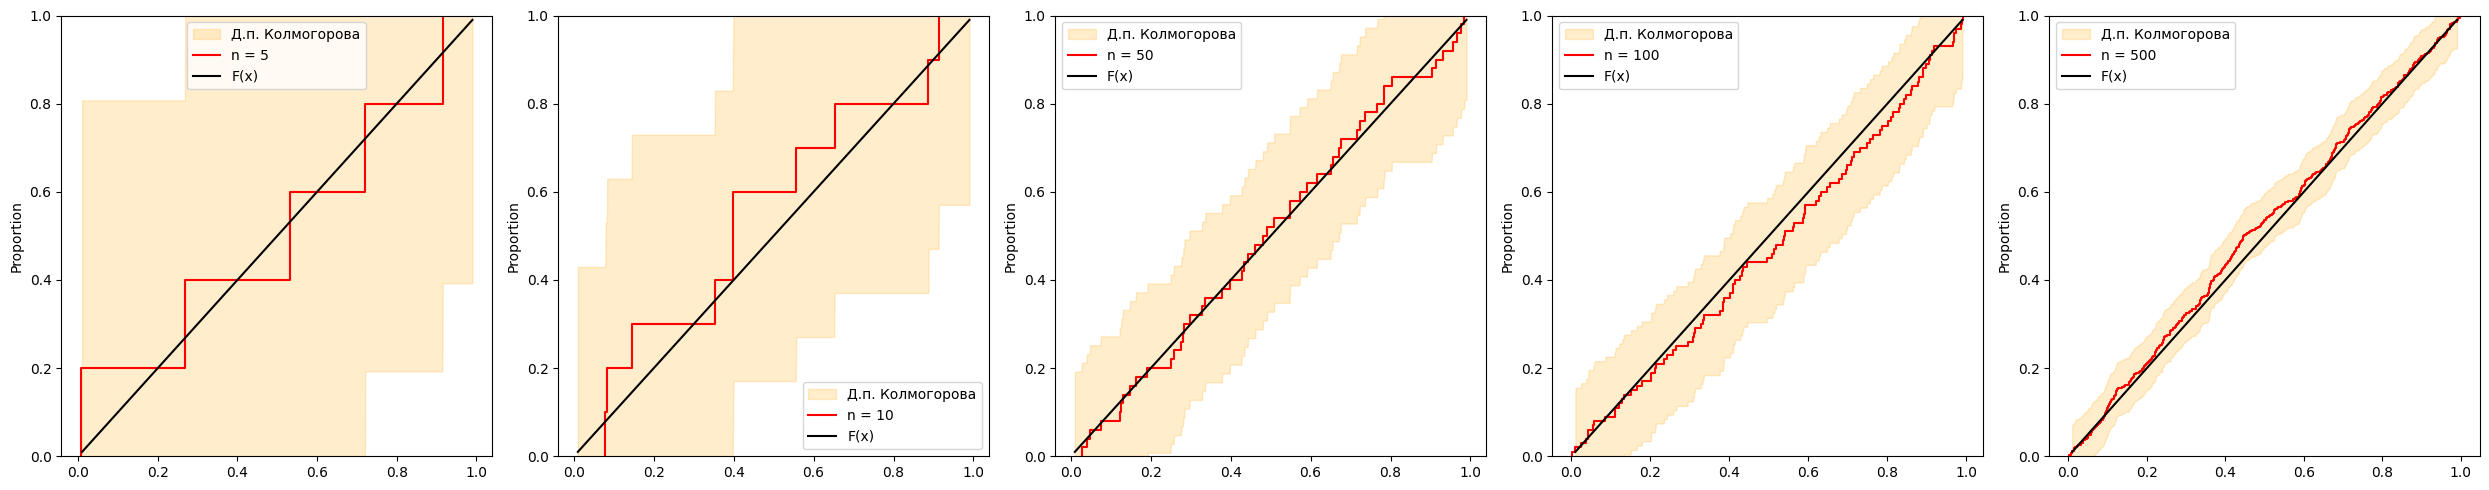

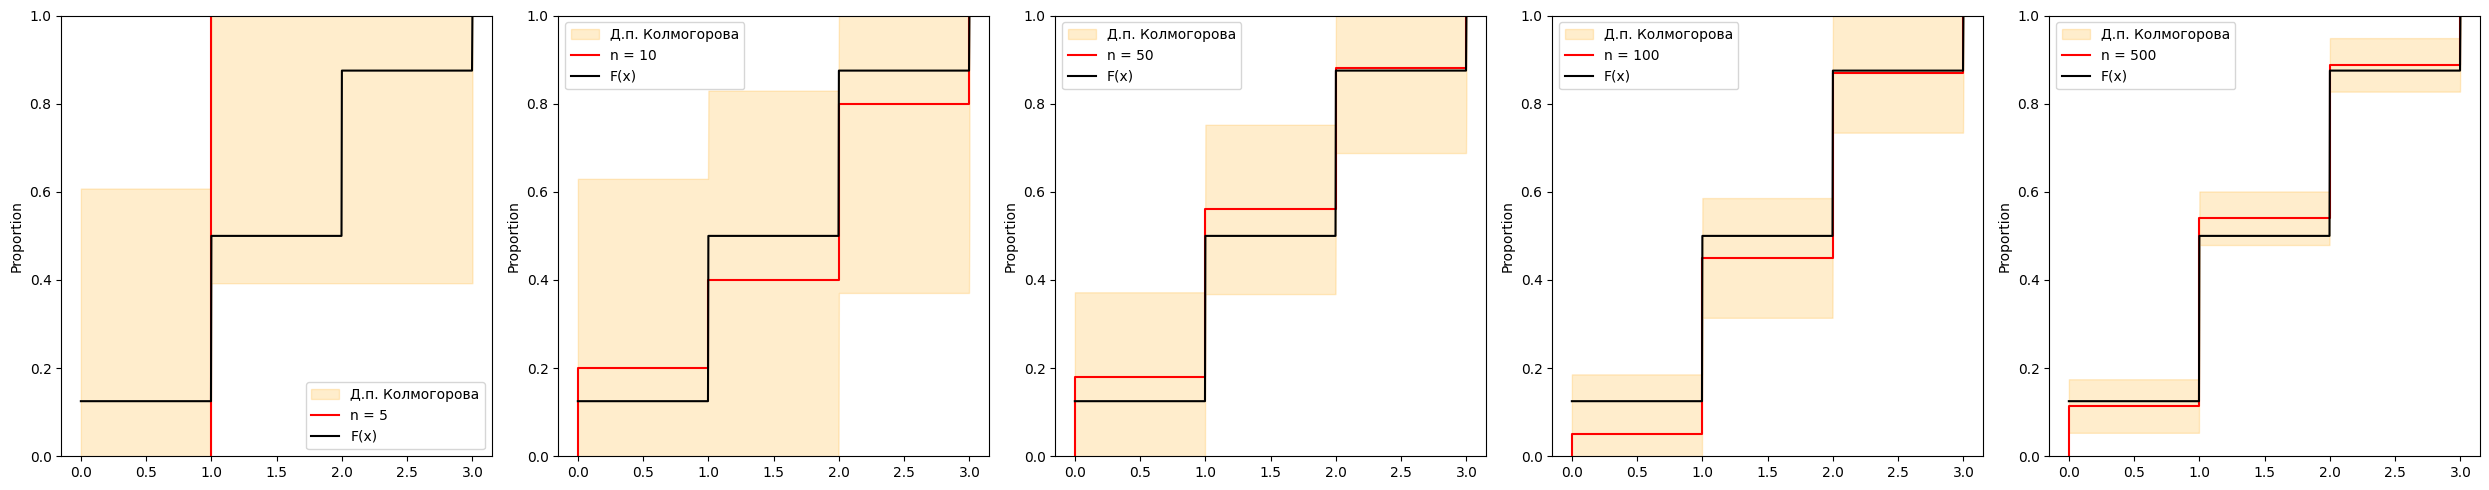

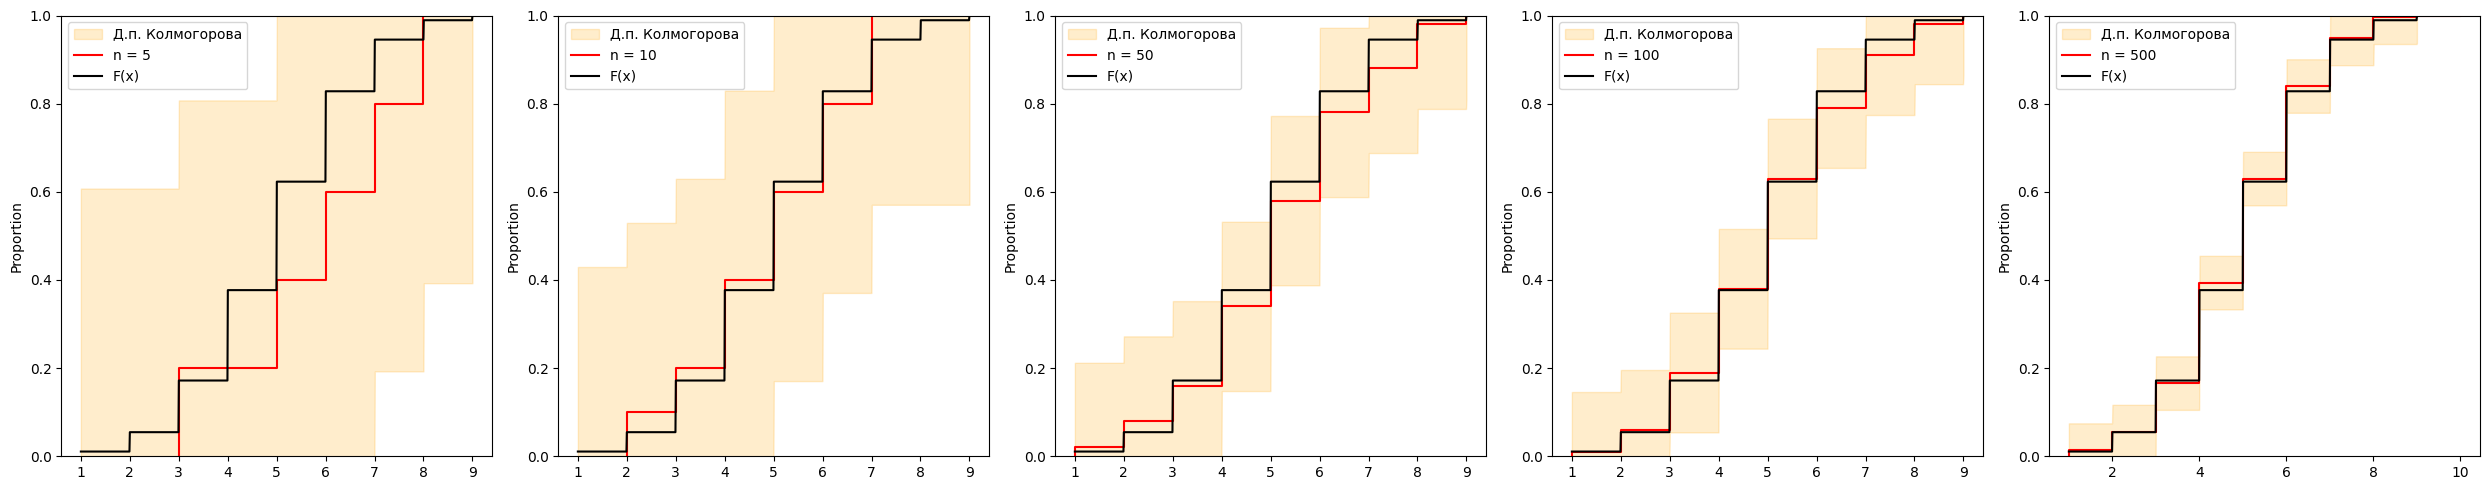

In [ ]:
n_vals = [5,10,50, 100, 500, 1000]
a = 0.05

def ecdf_comparison(dist, params, title, n_vals =[5,10,50, 100, 500]):
  fig, axes = plt.subplots(1, len(n_vals), figsize=(5*len(n_vals), 5))
  for j in range(len(n_vals)):
    n = n_vals[j]
    x_data= dist.rvs(**params ,size = n)
    min_x = dist.ppf(0.01, **params)
    max_x = dist.ppf(0.99, **params)
    x = np.linspace(min_x,max_x, 1000)

    x_data_sorted = np.sort(x_data)

    K = stats.kstwobign.ppf(1- a)/np.sqrt(n)
    ecdf = ECDF(x_data_sorted)
    y_ecdf = ecdf(x)
    k_lower = np.maximum(y_ecdf - K, 0)
    k_upper = np.minimum(y_ecdf + K, 1)
    axes[j].fill_between(x, k_lower, k_upper, alpha = 0.2, color = 'orange', label = 'Д.п. Колмогорова')

    y = np.sqrt(np.log(2 / a) / (2 * n))
    F_emp = np.arange(1, n + 1) / n
    F_dkw_lower = np.maximum(y_ecdf - y, 0)
    F_dkw_upper = np.minimum(y_ecdf + y, 1)
    #axes[j].fill_between(x, F_dkw_lower, F_dkw_upper, step='post',
                          #alpha=0.2, color='green', label=f'д.п. DKW')

    sns.ecdfplot(x_data,ax = axes[j], label = f'n = {n}', color = 'red')
    axes[j].plot(x, dist.cdf(x, **params), color = 'black', label = "F(x)")
    axes[j].legend()
  plt.tight_layout()
  plt.show()

ecdf_comparison(stats.norm, {'loc':0, 'scale':1}, title= 'N(0,1)')
ecdf_comparison(stats.uniform, {'loc': 0, 'scale': 1}, title="R[0,1]")
ecdf_comparison(stats.binom, {'n':3, 'p':0.5}, title ='Binom(3,0.5)')
ecdf_comparison(stats.binom, {'n':10, 'p':0.5}, title ='Binom(10,0.5)')



2) С помощью критерия Колмогорова проверить гипотезу H0 : Xi ∼ N (0, 1), если Xi = (Yi − EYi)/√DYi, где

(a) Yi ∼ N (−3, 8),

(b) Yi ∼ Bin(m, 1/2),

(c) Yi имеют распределение Ирвина–Холла (сумма m независимых равномерных с.в.).
Построить графики p-value для m = 1, 2, 5, 20. Рассмотреть выборки длины n = 50, 100, 500.

N(-3,8) test:
n = 50 : accepted = 0.95
n = 100 : accepted = 0.956
n = 500 : accepted = 0.959

Bin(m,1/2) test:
n = 50, m = 1 : accepted = 0.0
n = 50, m = 2 : accepted = 0.0
n = 50, m = 5 : accepted = 0.0
n = 50, m = 20 : accepted = 0.395
n = 100, m = 1 : accepted = 0.0
n = 100, m = 2 : accepted = 0.0
n = 100, m = 5 : accepted = 0.0
n = 100, m = 20 : accepted = 0.0
n = 500, m = 1 : accepted = 0.0
n = 500, m = 2 : accepted = 0.0
n = 500, m = 5 : accepted = 0.0
n = 500, m = 20 : accepted = 0.0

Irvin-Hall test:
n = 50, m = 1 : accepted = 0.862
n = 50, m = 2 : accepted = 0.955
n = 50, m = 5 : accepted = 0.952
n = 50, m = 20 : accepted = 0.952
n = 100, m = 1 : accepted = 0.761
n = 100, m = 2 : accepted = 0.947
n = 100, m = 5 : accepted = 0.948
n = 100, m = 20 : accepted = 0.951
n = 500, m = 1 : accepted = 0.067
n = 500, m = 2 : accepted = 0.914
n = 500, m = 5 : accepted = 0.929
n = 500, m = 20 : accepted = 0.945


TypeError: 'Text' object is not callable

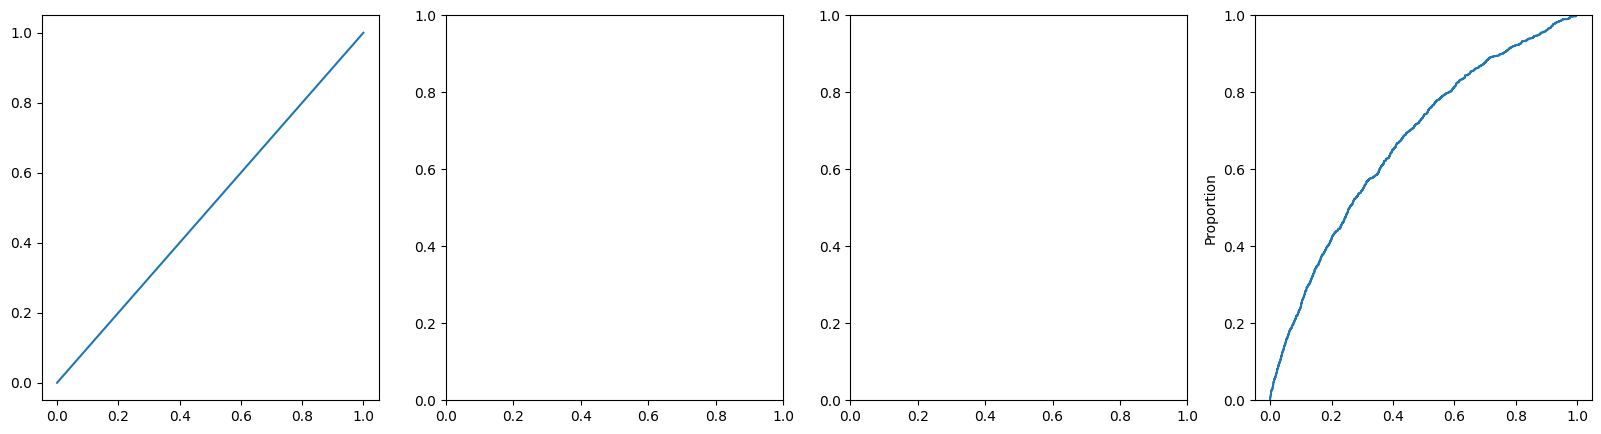

In [ ]:
n_val = [50,100,500]
m_val = [1, 2, 5, 20]
a = 0.05
k = 1000
fig, axes = plt.subplots(1, len(m_val), figsize=(5*len(m_val), 5))
###
print('N(-3,8) test:')
for n in n_val:
  accept = 0
  for i in range(k):
    y_data = stats.norm.rvs(-3, np.sqrt(8), size = n)
    x_data = [(i + 3)/np.sqrt(8) for i in y_data]
    D, pval = stats.kstest(x_data, stats.norm.cdf)

    if pval > a:
      accept+=1
  print(f'n = {n} : accepted = {accept / k}')
###
print('\nBin(m,1/2) test:')
for n in n_val:
  for m in m_val:
    accept = 0
    for i in range(k):
      y_data = stats.binom.rvs(m, 0.5, size = n)
      x_data = [(i - m/2)/np.sqrt(n/4) for i in y_data]
      D, pval = stats.kstest(x_data, stats.norm.cdf)

      if pval > a:
        accept+=1
    print(f'n = {n}, m = {m} : accepted = {accept / k}')
###
print('\nIrvin-Hall test:')
for n in n_val:
  for m in m_val:
    accept = 0
    for i in range(k):
      y_data = []
      for i in range(n):
        u_data = stats.uniform.rvs(0,1, size = m)
        y_data.append(sum(u_data))

      #y_data = stats.norm.rvs(-3, np.sqrt(8), size = n)
      x_data = [(i - m/2)/np.sqrt(m/12) for i in y_data]
      D, pval = stats.kstest(x_data, stats.norm.cdf)


      if pval > a:
        accept += 1
    print(f'n = {n}, m = {m} : accepted = {accept / k}')



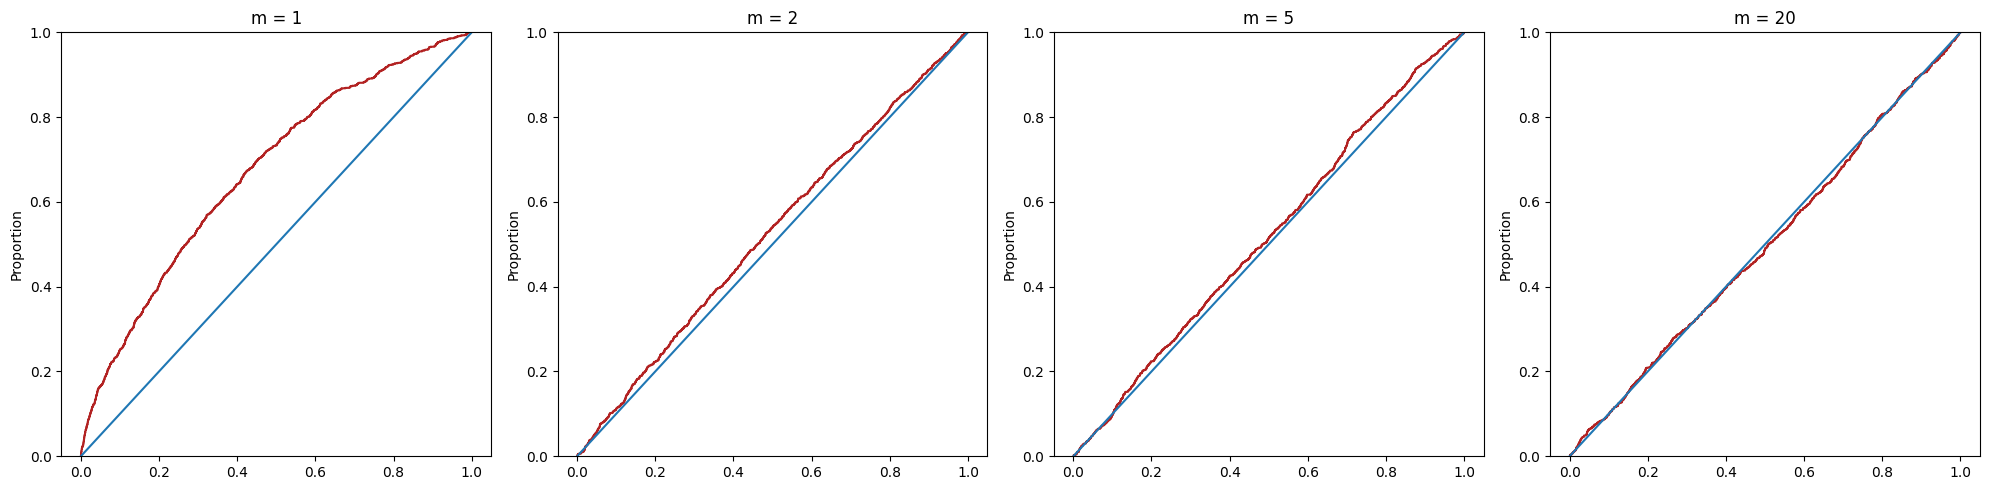

In [ ]:
n_val = [50,100,500]
m_val = [1, 2, 5, 20]
fig, axes = plt.subplots(1, len(m_val), figsize=(5*len(m_val), 5))
#p-value graphics
k = 1000
n = 50

p_val = []
for j in range(len(m_val)):
  m = m_val[j]
  p_val = []
  for i in range(k):
    #generate irvin-hall
    y_data = []
    for i in range(n):
      u_data = stats.uniform.rvs(0,1, size = m)
      y_data.append(sum(u_data))

    #y_data = stats.norm.rvs(-3, np.sqrt(8), size = n)
    x_data = [(i - m/2)/np.sqrt(m/12) for i in y_data]
    D, pval = stats.kstest(x_data, stats.norm.cdf)
    p_val.append(pval)
  sns.ecdfplot(p_val, ax = axes[j], color='firebrick')
  x = np.linspace(0,1,1000)
  axes[j].plot(x,x)
  axes[j].set_title(f"m = {m}")
plt.tight_layout()


3) Если выборка имеет нормальное распределение с неизвестными параметрами, то можно попробовать перейти от выборки Xi к (Xi−X)/S и применить к ним критерий Колмогорова нормальности N (0, 1). Построить график p-value при верной гипотезе и посмотреть корректно ли работает ”модифицированный” критерий.

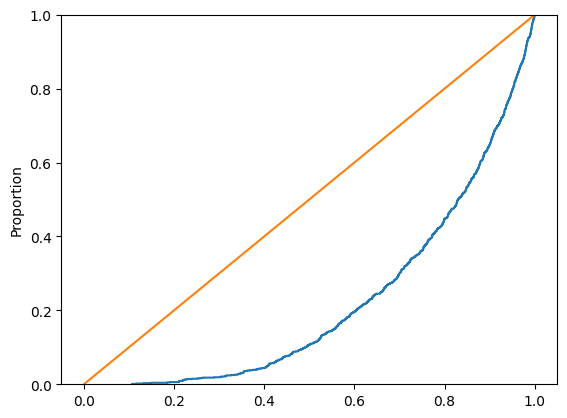

In [ ]:
n = 100
k = 1000
mu = 3
sigma = 2
p_val = []

for i in range(k):
  x_data = stats.norm.rvs(mu,sigma, size = n)
  x_mod = (x_data-np.mean(x_data))/np.sqrt(np.var(x_data))
  D, pval = stats.kstest(x_mod, stats.norm.cdf)
  p_val.append(pval)

x= np.linspace(0,1,1000)
sns.ecdfplot(p_val)
plt.plot(x,x)
